# ***packages***

In [1]:
import matplotlib.pyplot as plt
import scanpy as sc
import numpy as np

# ***data***

In [2]:
data_dir = './data/Mouse_brain_MERFISH/'

age='4wk'

data1="adata90wk_donor_id_2_slice_0"
data2="adata90wk_donor_id_5_slice_1"

sliceA = sc.read_h5ad(data_dir + data1 + ".h5ad")
sliceB = sc.read_h5ad(data_dir + data2 + ".h5ad")


# ***Age Progression Score***

*Note: Make sure the run the alignment for the respective dataset before running this code. This code requires the cosine distance of gene expression and the pi matrix that will be stored to `local_data` directory once you run the alignment pipeline.*

In [3]:
filePath = './local_data/promt'

cosine_dist_gene_expr = np.load(f"{filePath}/cosine_dist_gene_expr_{data1}_{data2}.npy")
pi_mat = np.load(f"{filePath}/pi_matrix_{data1}_{data2}.npy")

# taking cost matrix as the all pair cosine_dist_gene_expr between slices
age_progression_score_mat = pi_mat * cosine_dist_gene_expr

sliceA.obs['age_progression_score'] = np.sum(age_progression_score_mat, axis=1, dtype=np.float64) / (1 / sliceA.n_obs) * 100
sliceB.obs['age_progression_score'] = np.sum(age_progression_score_mat, axis=0, dtype=np.float64) / (1 / sliceA.n_obs) * 100

In [4]:
def filter_cells_by_count(adata, threshold):

    cell_type_counts = adata.obs['cell_type_annot'].value_counts()
    valid_cell_types = cell_type_counts[cell_type_counts >= threshold].index.tolist()

    return adata[adata.obs['cell_type_annot'].isin(valid_cell_types)]

In [5]:
sliceA = filter_cells_by_count(sliceA, 10)

import random
random.seed(82)
def generate_random_colors(num_colors):
    colors = []
    for _ in range(num_colors):
        colors.append((random.random(), random.random(), random.random()))
    return colors

unique_cell_types = sliceA.obs['cell_type_annot'].unique()
random_colors = generate_random_colors(len(unique_cell_types))

color_map = dict(zip(unique_cell_types, random_colors))

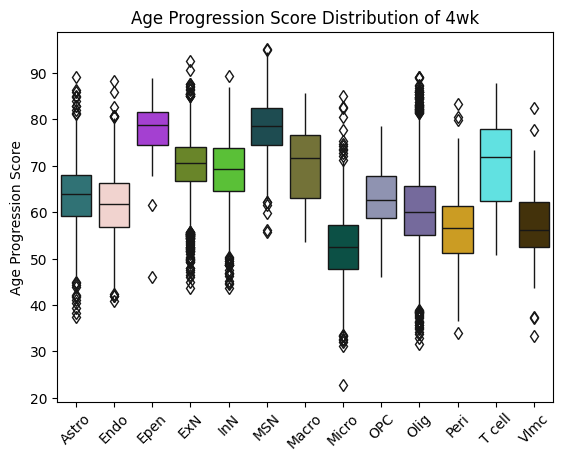

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(x="cell_type_annot", y="age_progression_score", 
            data=sliceA.obs,
            palette = color_map.values(), hue = sliceA.obs['cell_type_annot'], 
            notch=False, showcaps=False, flierprops={"marker": "d"},)
plt.xlabel("")
plt.ylabel("Age Progression Score")
plt.xticks(rotation=45)
plt.title(f"Age Progression Score Distribution of {age}")
plt.show()


# ***heatmap of age prog score by cell type***

In [ ]:

import os
if not os.path.exists(f'./age-prog-cell/heatmap/{age}'):
    os.makedirs(f'./age-prog-cell/heatmap/{age}')


import matplotlib.pyplot as plt
for cell_type in unique_cell_types:

    df_cell_type = sliceA[sliceA.obs['cell_type_annot'] == cell_type]
    plt.figure(figsize=(10,10))
    plt.scatter(sliceA.obsm["spatial"][:, 0], sliceA.obsm["spatial"][:, 1], c = 'gray', s= 2, alpha=.2)
    plt.scatter(df_cell_type.obsm["spatial"][:, 0], df_cell_type.obsm["spatial"][:, 1], s=20, c= df_cell_type.obs['age_progression_score'], cmap='viridis')
    plt.title(f'Age Progression Score Heatmap for {cell_type}')
    plt.axis("off")
    plt.colorbar()
    plt.show()
    plt.clf()

# ***neighborhood count on age prog score***

In [6]:
from sklearn.metrics.pairwise import euclidean_distances
from tqdm import tqdm
def get_niche_distribution(curr_slice, radius):
    """
    This method is added by Anup Bhowmik
    Args:
        curr_slice: Slice to get niche distribution for.
        pairwise_distances: Pairwise distances between cells of a slice.
        radius: Radius of the niche.

    Returns:
        niche_distribution: Niche distribution for the slice.
    """

    print ("radius", radius)

    unique_cell_types = np.array(list(curr_slice.obs['cell_type_annot'].unique()))
    cell_type_to_index = dict(zip(unique_cell_types, list(range(len(unique_cell_types)))))
    cells_within_radius = np.zeros((curr_slice.shape[0], len(unique_cell_types)), dtype=float)

    # print("time taken for cell type", time_cell_type_end-time_cell_type_start)

    source_coords = curr_slice.obsm['spatial']
    distances = euclidean_distances(source_coords, source_coords)

    for i in tqdm(range(curr_slice.shape[0])):
        # find the indices of the cells within the radius

        target_indices = np.where(distances[i] <= radius)[0]
        # print("i", i)
        # print(target_indices)

        for ind in target_indices:
            cell_type_str_j = str(curr_slice.obs['cell_type_annot'][ind])
            cells_within_radius[i][cell_type_to_index[cell_type_str_j]] += 1

    return np.array(cells_within_radius), unique_cell_types

In [7]:
neighborhood_counts, unique_cell_types = get_niche_distribution(sliceA, 100)


radius 100


100%|██████████| 11047/11047 [00:03<00:00, 3646.38it/s]


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import os

if not os.path.exists(f'./age-prog-cell/linear-regression/{age}'):
    os.makedirs(f'./age-prog-cell/linear-regression/{age}')
    

# create the file
with open(f'./age-prog-cell/linear-regression/{age}/{age}_linear_regression.txt', 'w') as f:
    f.write(f"Linear Regression R2 scores for {age} slice\n")


for k in range(unique_cell_types.shape[0]):    
    for j in range(unique_cell_types.shape[0]):
        X = []
        y = []
        for i in range(sliceA.n_obs):
        
            if sliceA.obs['cell_type_annot'].iloc[i] == unique_cell_types[k]:
                X.append(neighborhood_counts[i][j])
                y.append(sliceA.obs['age_progression_score'].iloc[i])

        X = np.array(X).reshape(-1, 1)
        y = np.array(y).reshape(-1, 1)    
        # Fit the linear regression model
        regressor = LinearRegression()
        regressor.fit(X, y)

        # Predict the age_progression_score based on the count of neighboring cells
        y_pred = regressor.predict(X)

        # Calculate the R2 score
        r2 = r2_score(y, y_pred)

        # write to file
        with open(f'./age-prog-cell/linear-regression/{age}/{age}_linear_regression.txt', 'a') as f:
            f.write(f"{unique_cell_types[k]} and {unique_cell_types[j]} \t {r2}\n")

        # Plot the linear regression line
        
        plt.scatter(X, y, color='red')
        plt.plot(X, y_pred, color='blue')
        plt.title(f'Linear Regression between {unique_cell_types[k]} and {unique_cell_types[j]}')
        plt.xlabel('Number of neighboring cells')
        plt.ylabel('Age Progression Score')
        plt.show()
        # plt.savefig(f'./age-prog-cell/linear-regression/{age}/{age}_{unique_cell_types[k]}_{unique_cell_types[j]}.png', bbox_inches='tight')
        plt.clf()
                
     

In [60]:

# import os
# if not os.path.exists(f'./age-prog-cell/neighborhood-count/{age}'):
#     os.makedirs(f'./age-prog-cell/neighborhood-count/{age}')

# for k in range(unique_cell_types.shape[0]):    
#     for j in range(unique_cell_types.shape[0]):
#         for i in range(sliceA.n_obs):
        
#             if sliceA.obs['cell_type_annot'].iloc[i] == unique_cell_types[k]:
#                 plt.scatter(neighborhood_counts[i][j], sliceA.obs['age_progression_score'].iloc[i], c='red', s=4)
#         # plt.title(f'Age Progression Score of {unique_cell_types[k]} vs Neighborhood Count of {unique_cell_types[j]}')
#         # plt.show()
#         plt.savefig(f'./age-prog-cell/neighborhood-count/{age}/' + age + unique_cell_types[k] + '-vs-neighborhood-count-' + unique_cell_types[j] + '.png', transparent=False, bbox_inches='tight', pad_inches=0.1)
#         plt.clf()